In [ ]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv ("Labeling.csv")

In [ ]:
df = data

In [ ]:
df.head (10)

,text,text_clean,token,stop,stemmed,sentiment
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",netral
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",netral
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",netral
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",netral
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",netral
5,Ganjar Pranowo mengajak partai politik penduku...,ganjar pranowo mengajak partai politik penduku...,"['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...",netral
6,Bakal calon presiden (bacapres) dari Partai Ge...,bakal calon presiden bacapres dari partai geri...,"['bakal', 'calon', 'presiden', 'bacapres', 'da...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...",netral
7,@yodisss Seneng bgt nih pasti masyarakat Lombo...,yodisss seneng bgt nih pasti masyarakat lombok...,"['yodisss', 'seneng', 'bgt', 'nih', 'pasti', '...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...",netral
8,Bakal calon presiden yang juga Menteri Pertaha...,bakal calon presiden yang juga menteri pertaha...,"['bakal', 'calon', 'presiden', 'yang', 'juga',...","['bakal', 'calon', 'presiden', 'menteri', 'per...","['bakal', 'calon', 'presiden', 'menteri', 'per...",netral
9,Mereka yg masih mempersoalkan seorang presiden...,mereka yg masih mempersoalkan seorang presiden...,"['mereka', 'yg', 'masih', 'mempersoalkan', 'se...","['yg', 'mempersoalkan', 'seorang', 'presidenca...","['yg', 'mempersoalkan', 'seorang', 'presidenca...",netral


In [ ]:
data.shape

(3142, 6)

In [ ]:
import re
def praproses(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)()(?:-)?(?:\)|\(|D|P)',
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))
    return text

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment'],
                                                    test_size = 0.20,
                                                    random_state = 42)

In [ ]:
X_train.shape, X_test.shape

((2513,), (629,))

In [ ]:
df ['text'] = df['text'].astype('str')
df ['sentiment'] = df['sentiment'].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3142 non-null   object
 1   text_clean  3142 non-null   object
 2   token       3142 non-null   object
 3   stop        3142 non-null   object
 4   stemmed     3142 non-null   object
 5   sentiment   3142 non-null   object
dtypes: object(6)
memory usage: 147.4+ KB


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_Vectorizer = TfidfVectorizer()
tfidf_train = tfidf_Vectorizer.fit_transform(X_train)
tfidf_test = tfidf_Vectorizer.fit_transform(X_test)

In [ ]:
print (X_train.shape)
print (y_train.shape)
print (X_test.shape)
print (y_test.shape)

(2513,)
(2513,)
(629,)
(629,)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
vectorizer.fit(X_train)

CountVectorizer()

In [ ]:
X_train = vectorizer.transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

  (0, 86)	1
  (0, 1416)	1
  (0, 1539)	1
  (0, 2113)	1
  (0, 2437)	1
  (0, 2442)	1
  (0, 2867)	1
  (0, 4711)	1
  (0, 5847)	1
  (0, 6390)	1
  (1, 86)	1
  (1, 1416)	1
  (1, 1539)	1
  (1, 2112)	1
  (1, 2399)	1
  (1, 2437)	1
  (1, 2456)	1
  (1, 2867)	1
  (2, 86)	1
  (2, 481)	1
  (2, 491)	1
  (2, 1187)	1
  (2, 1213)	1
  (2, 1266)	1
  (2, 1416)	1
  :	:
  (2511, 3424)	1
  (2511, 3596)	1
  (2511, 3754)	1
  (2511, 3962)	1
  (2511, 4455)	1
  (2511, 5068)	1
  (2511, 5246)	1
  (2511, 5300)	1
  (2511, 5632)	2
  (2511, 5669)	1
  (2511, 5847)	2
  (2511, 5854)	1
  (2511, 5886)	1
  (2511, 5935)	1
  (2511, 6734)	2
  (2511, 6796)	1
  (2511, 7173)	1
  (2511, 7305)	1
  (2511, 7447)	2
  (2511, 7814)	1
  (2512, 86)	1
  (2512, 1416)	1
  (2512, 1694)	1
  (2512, 6509)	1
  (2512, 7555)	1


In [ ]:
print(X_test)

  (0, 86)	1
  (0, 401)	1
  (0, 484)	1
  (0, 577)	1
  (0, 839)	1
  (0, 890)	1
  (0, 934)	1
  (0, 1416)	1
  (0, 2038)	1
  (0, 2089)	2
  (0, 2252)	1
  (0, 2533)	1
  (0, 3096)	1
  (0, 3518)	1
  (0, 5198)	1
  (0, 5374)	1
  (0, 5425)	1
  (0, 5462)	1
  (0, 5474)	1
  (0, 5480)	1
  (0, 5511)	1
  (0, 5785)	2
  (0, 5817)	1
  (0, 6046)	1
  (0, 6064)	1
  :	:
  (627, 86)	1
  (627, 617)	1
  (627, 621)	1
  (627, 930)	1
  (627, 1416)	1
  (627, 1417)	1
  (627, 1539)	1
  (627, 1751)	1
  (627, 2294)	1
  (627, 2437)	1
  (627, 2463)	1
  (627, 2867)	1
  (627, 3264)	2
  (627, 3424)	1
  (627, 3984)	1
  (627, 5831)	1
  (627, 5837)	1
  (627, 5920)	1
  (627, 6843)	2
  (627, 7031)	1
  (627, 7290)	1
  (627, 7531)	1
  (628, 86)	1
  (628, 895)	1
  (628, 1416)	1


In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(tfidf_train, y_train)

MultinomialNB()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3142 non-null   object
 1   text_clean  3142 non-null   object
 2   token       3142 non-null   object
 3   stop        3142 non-null   object
 4   stemmed     3142 non-null   object
 5   sentiment   3142 non-null   object
dtypes: object(6)
memory usage: 147.4+ KB


In [ ]:
predicted = nb.predict(X_test)
predicted

array(['netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netr

In [ ]:
score = accuracy_score(y_test, predicted)

In [ ]:
print ( "accuracy_score:" , score*100, '%')
print ('====================================================\n')
print(f'confusion_matrix:\n {confusion_matrix(y_test, predicted)}')
print('====================================================\n')
print(classification_report(y_test, predicted))



accuracy_score: 95.07154213036566 %

confusion_matrix:
 [[  0   6   0]
 [  0 598   0]
 [  0  25   0]]

              precision    recall  f1-score   support

     negatif       0.00      0.00      0.00         6
      netral       0.95      1.00      0.97       598
     positif       0.00      0.00      0.00        25

    accuracy                           0.95       629
   macro avg       0.32      0.33      0.32       629
weighted avg       0.90      0.95      0.93       629



C:\Users\Fadli\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Fadli\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Fadli\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
conf_matrix = confusion_matrix (y_test, predicted)

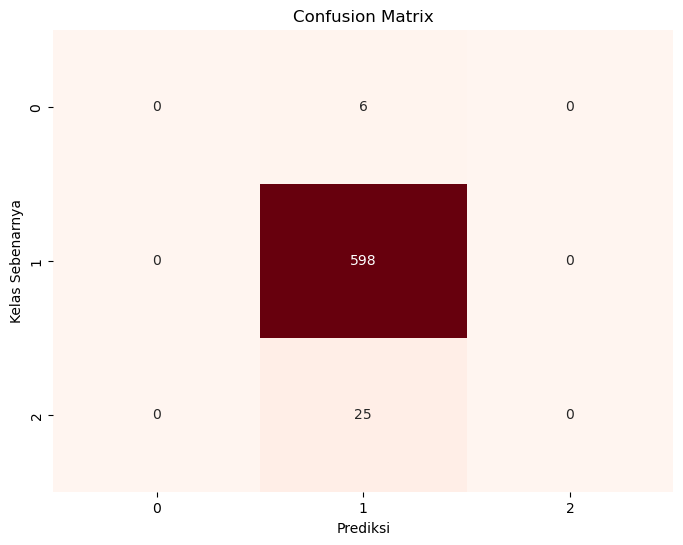

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Prediksi')
plt.ylabel('Kelas Sebenarnya')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
jumlah_positif = 6
jumlah_netral = 598
jumlah_negatif = 25

In [ ]:
sentiments = ['Positif','netral', 'Negatif']
counts = [jumlah_positif, jumlah_netral, jumlah_negatif]

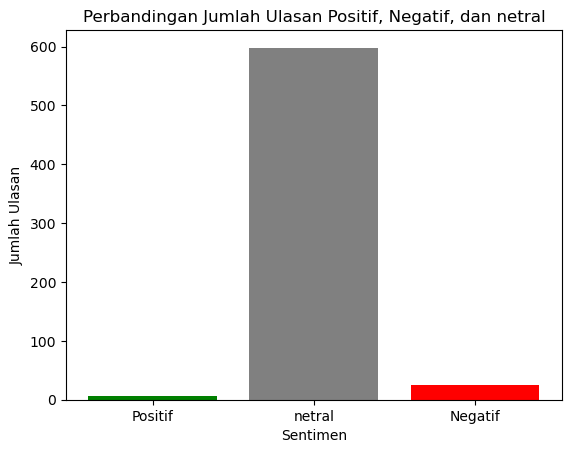

In [ ]:
plt.bar(sentiments, counts, color=['green', 'gray', 'red'])
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.title('Perbandingan Jumlah Ulasan Positif, Negatif, dan netral')
plt.show()